# Reading The Data
***

In [1]:
import pandas as pd
data = pd.read_csv('../Data/healthcare-dataset-stroke-data.csv')

# Exploring The Data
***

## Exploring the Dataset Structure

The dataset used in this project is contained in a single CSV file and consists of **5,110 observations** and **12 attributes**, including both numerical and categorical features describing patients' demographic information, medical history, lifestyle factors, and health conditions. The **stroke** column represents the target variable to be predicted.

An initial exploration of the dataset showed that there are **no duplicate records**. Among the numerical attributes, **missing values are present only in the `bmi` column**, which contains **201 missing values**, while all other attributes are complete. The dataset contains **four integer attributes**, **three floating-point attributes**, and **five categorical attributes**.

An examination of the unique values in the categorical attributes revealed that the data is generally clean and well-structured. The categorical features contain a limited number of valid categories with no inconsistencies or unexpected entries. For example, the `gender` attribute includes three categories (`Male`, `Female`, and `Other`), while the remaining categorical attributes contain meaningful and consistent values, making the dataset suitable for further preprocessing and analysis.


In [2]:
print('Dataset Information: ')
data.info()

print('\n========================================================================================')
print('Dataset Shape: ')
print(data.shape)

print('\n========================================================================================')
print('Dataset Columns: ')
print(data.columns)

print('\n========================================================================================')
print('Dataset Columns Data types: ')
print(data.dtypes)

print('\n========================================================================================')
print('Dataset Missing Values: ')
print(data.isna().sum())

print('\n========================================================================================')
print('Dataset Duplicate Rows: ')
print(data.duplicated().sum())


Dataset Information: 
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB

Dataset Shape: 
(5110, 12)

Dataset Columns: 
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Res

In [3]:
for column in data.select_dtypes(include=['object', 'string', 'str']):
    print(f"\nColumn: {column}")
    print(data[column].unique())
    print('-'*50)


Column: gender
<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
--------------------------------------------------

Column: ever_married
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------

Column: work_type
<ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
--------------------------------------------------

Column: Residence_type
<ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str
--------------------------------------------------

Column: smoking_status
<ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str
--------------------------------------------------


### Checking Records with the "Other" Gender Category

The following code retrieves all observations where the gender is **"Other"**.

In [4]:
data[data['gender'] == 'Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


### Data Samples

In [5]:
print('Dataset Samples (head): ')
data.head()

Dataset Samples (head): 


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
print('Dataset Samples (tail): ')
data.tail()

Dataset Samples (tail): 


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


### EXPLORING THE STATISTICS

In [7]:
print('Dataset Description: ')
data.describe()

Dataset Description: 


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### Outlier Identification
Outlier detection was performed to identify unusual data points that could influence the statistical analysis or affect the performance of predictive models.

However, not all numerical columns in the dataset are suitable for this analysis. Columns such as id, hypertension, heart_disease, and stroke contain identifiers or binary values (0 and 1), where outliers have no practical meaning. Therefore, we limited our examination to the three continuous variables: age, avg_glucose_level, and bmi.

The Interquartile Range (IQR) method was applied to these columns to detect statistical outliers. This approach identifies values that lie below the first quartile (Q1) minus 1.5 times the IQR, or above the third quartile (Q3) plus 1.5 times the IQR. Boxplots were also generated to visually represent these outliers and their relation to stroke occurrence.

From the visualizations, we observed that the avg_glucose_level and bmi features contained noticeable outliers, whereas the age feature showed a more evenly distributed range of values with no significant outliers. The boxplots also revealed that patients diagnosed with stroke tend to be older and generally have higher average glucose levels than those without stroke. In contrast, the distribution of bmi is relatively similar between the two groups, suggesting a weaker visual relationship with stroke occurrence compared to age and average glucose level. The detected outliers, particularly in avg_glucose_level and bmi, will be carefully considered during the preprocessing stage, as they may represent genuine extreme medical cases rather than data entry errors.

Outlier count using the IQR method:

age: 0 outliers
avg_glucose_level: 627 outliers
bmi: 110 outliers


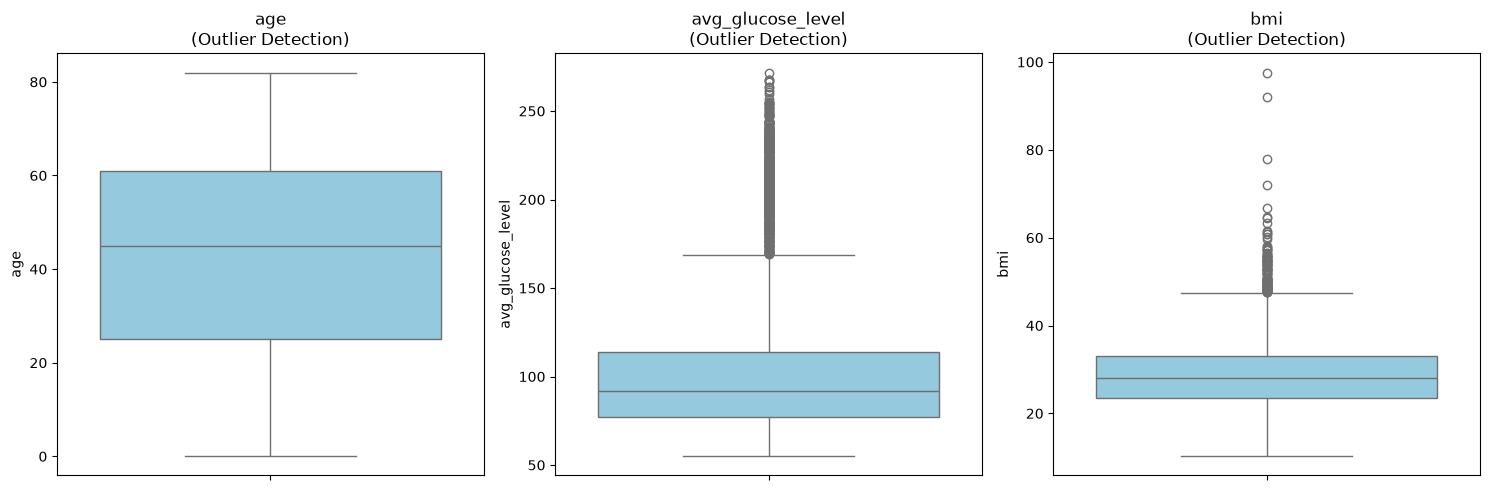

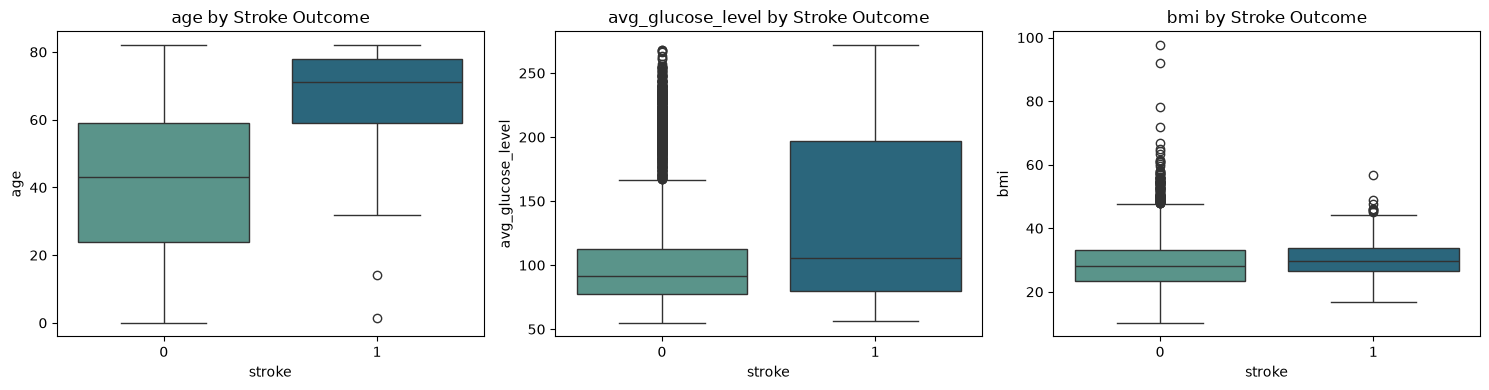

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the valid numeric columns for outlier detection
valid_numeric_cols = ['age', 'avg_glucose_level', 'bmi']


# STATISTICAL METHOD (IQR)
# ----------------------------------------------------------
print("Outlier count using the IQR method:\n")

for col in valid_numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")


# VISUAL METHOD (BOXPLOTS)
# ----------------------------------------------------------
plt.figure(figsize=(15, 5))
for i, col in enumerate(valid_numeric_cols, 1):
    plt.subplot(1, len(valid_numeric_cols), i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(f"{col}\n(Outlier Detection)")
plt.tight_layout()
plt.show()


# VISUALIZE OUTLIERS BY STROKE OUTCOME
# ----------------------------------------------------------
plt.figure(figsize=(15, 4))
for i, col in enumerate(valid_numeric_cols, 1):
    plt.subplot(1, len(valid_numeric_cols), i)
    sns.boxplot(
        x='stroke',
        y=col,
        data=data,
        hue='stroke',
        palette='crest',
        legend=False
    )
    plt.title(f"{col} by Stroke Outcome")
plt.tight_layout()
plt.show()

#### Identifying Key Features
Before performing correlation analysis, the categorical attributes were label-encoded to make them numerically comparable with the target column. This straightforward encoding approach was sufficient for our purpose of gaining an initial understanding of the dataset, without delving into more complex statistical tests such as chi-square analysis.

After encoding, we computed the correlation of each feature with the target variable (stroke). The analysis revealed that age, heart_disease, avg_glucose_level, hypertension, and ever_married have the highest positive correlations with stroke occurrence. Among them, age shows the strongest correlation (≈0.25), followed by heart_disease (≈0.13) and avg_glucose_level (≈0.13).

These results align well with domain logic and medical intuition: older individuals are naturally at higher risk, and conditions such as heart disease, hypertension, and elevated glucose levels are medically recognized as major risk factors for stroke. Even the correlation with marital status may reflect lifestyle or stress-related influences observed in healthcare studies.

A bar chart was used to visualize the top five features most correlated with stroke, offering a clear view of the strongest predictors that are likely to play a key role in building the model.

Correlation of all features with 'stroke':

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.042374
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
work_type           -0.032316
Name: stroke, dtype: float64


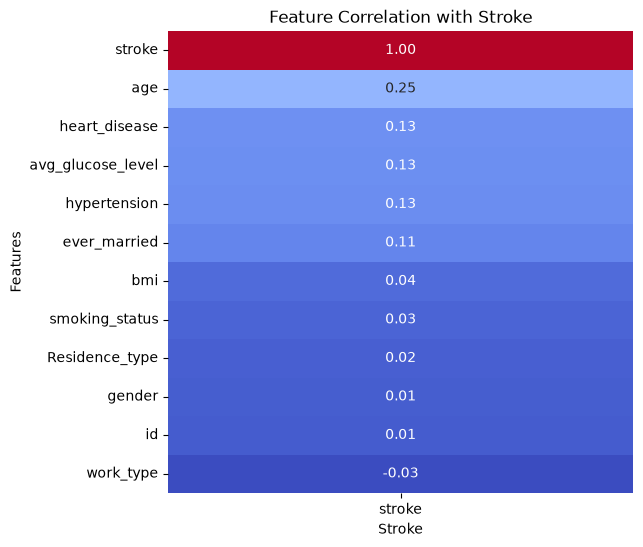

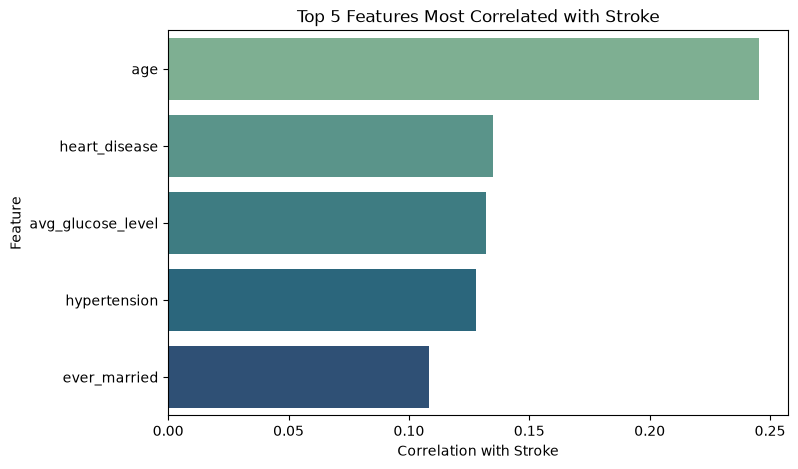

In [13]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to preserve the original data
data_encoded = data.copy()

# ----------------------------------------
# ENCODE CATEGORICAL FEATURES
# ----------------------------------------
encoder = LabelEncoder()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    data_encoded[col] = encoder.fit_transform(data_encoded[col].astype(str))

# ----------------------------------------
# COMPUTE CORRELATION WITH TARGET
# ----------------------------------------
corr_matrix = data_encoded.corr()
corr_with_stroke = corr_matrix['stroke'].sort_values(ascending=False)

print("Correlation of all features with 'stroke':\n")
print(corr_with_stroke)

# ----------------------------------------
# VISUALIZE CORRELATION WITH TARGET ONLY
# ----------------------------------------
plt.figure(figsize=(6, 6))
sns.heatmap(corr_with_stroke.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title("Feature Correlation with Stroke")
plt.xlabel("Stroke")
plt.ylabel("Features")
plt.show()

# ----------------------------------------
# VISUALIZE TOP 5 FEATURES
# ----------------------------------------
top_features = corr_with_stroke.drop('stroke').head(5)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,
    palette='crest',
    legend=False
)
plt.title("Top 5 Features Most Correlated with Stroke")
plt.xlabel("Correlation with Stroke")
plt.ylabel("Feature")
plt.show()

#### DISTRIBUTION OF HEALTH-RELATED DATA POINTS
To better understand the composition of the dataset and the characteristics of the population, we examined the distribution of both numerical and categorical attributes. This helps reveal how the health and lifestyle factors are distributed, identify potential imbalances among categories, and detect patterns that may influence stroke risk.

We analyzed the numerical variables—age, avg_glucose_level, and bmi—using histograms with kernel density estimates (KDE). The age distribution is concentrated around middle-aged and older individuals, although all age groups are represented in the dataset. The avg_glucose_level feature exhibits a clear right-skewed distribution, indicating that a subset of patients has considerably higher glucose levels, which may reflect diabetic conditions. The bmi distribution is unimodal with a slight positive skew, centered around the healthy-to-overweight range, with a small number of high-value outliers.

For the categorical attributes—gender, ever_married, work_type, Residence_type, and smoking_status—count plots were used to visualize their frequencies. The dataset appears reasonably balanced across most variables, although certain categories, such as Private work type, are noticeably more frequent. Additionally, the Urban and Rural residence categories are nearly balanced, while the Never worked category contains only a small number of observations. These distributions provide valuable insight into the characteristics of the study population before proceeding with predictive modeling.

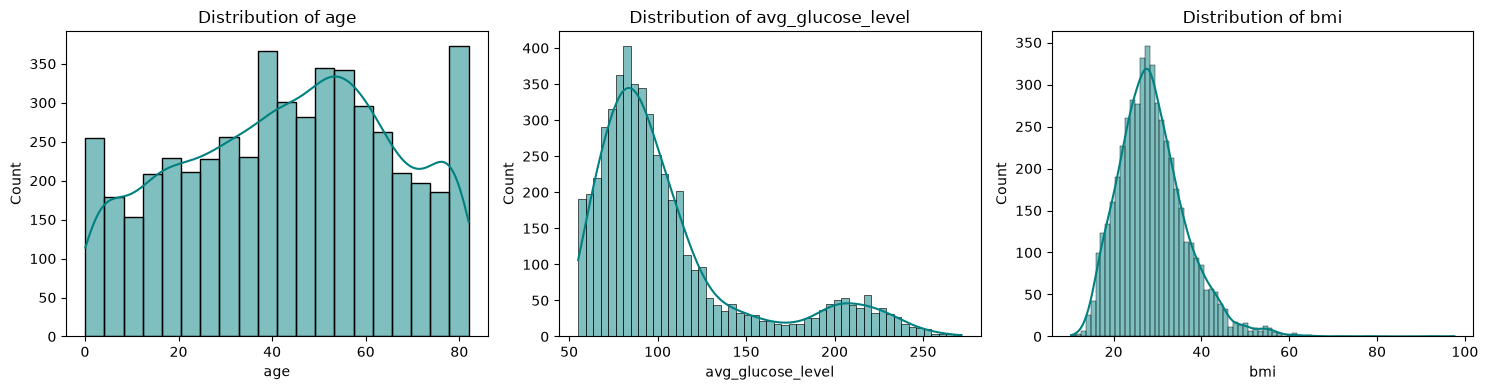

In [15]:
# Numeric
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.histplot(data[col], kde=True, color='teal')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

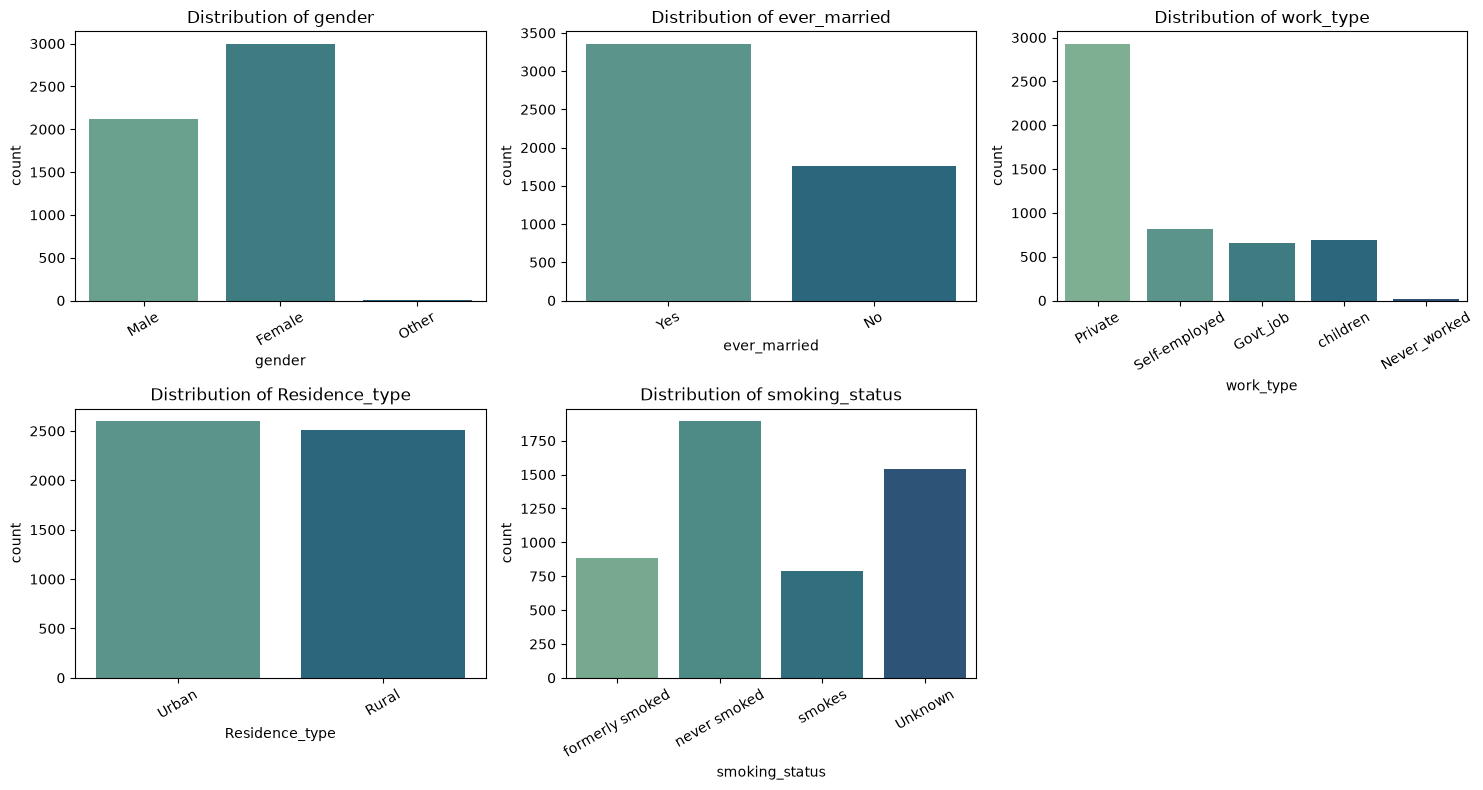

In [17]:
# Categorical
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(
        x=col,
        data=data,
        hue=col,
        palette='crest',
        legend=False
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### POTENTIAL PATTERNS
To explore possible relationships within the data, we examined how certain health and lifestyle factors vary between individuals who experienced a stroke and those who did not. The focus was on age, average glucose level, and smoking status, as these are commonly associated with stroke risk.

The visualizations suggest a clear upward trend between age and stroke occurrence, indicating that the likelihood of stroke tends to rise with increasing age. This observation aligns with well-known medical patterns where older adults face higher risks.

We also noticed that stroke cases appear to be relatively more common among individuals with higher average glucose levels, suggesting that elevated blood glucose may be associated with an increased risk of stroke.

For smoking status, the relationship was less distinct, though the plot still helps highlight possible lifestyle effects worth exploring further.

These initial visual patterns do not imply causation but serve as valuable hints when deciding which features to prioritize for predictive modeling in later stages.

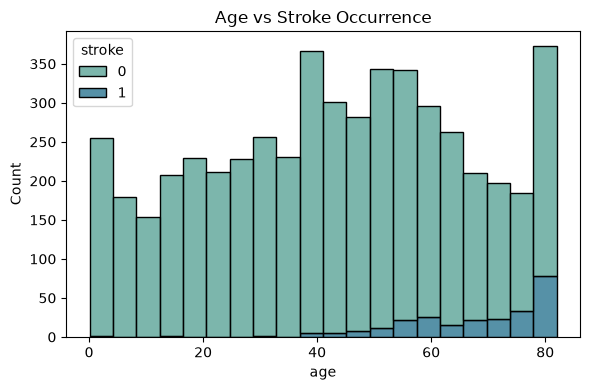

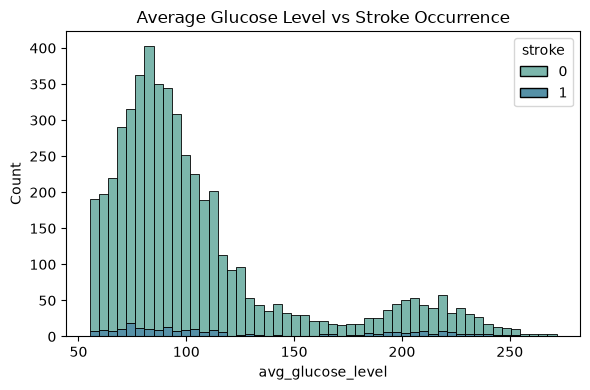

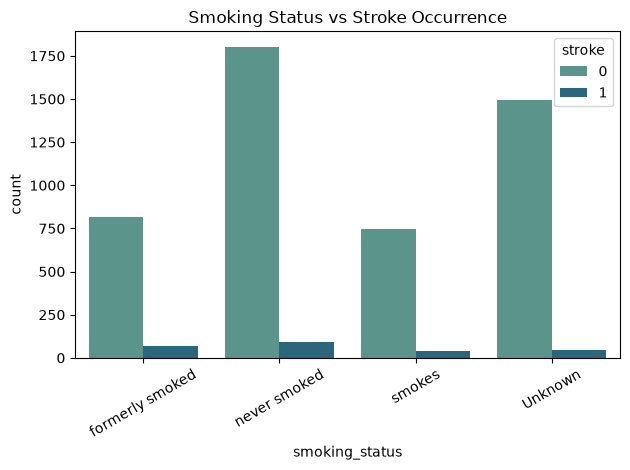

In [20]:
# Does stroke risk rise with age?
plt.figure(figsize=(6,4))
sns.histplot(
    data=data,
    x='age',
    hue='stroke',
    multiple='stack',
    palette='crest'
)
plt.title("Age vs Stroke Occurrence")
plt.tight_layout()
plt.show()

# Is high glucose linked to stroke?
plt.figure(figsize=(6,4))
sns.histplot(
    data=data,
    x='avg_glucose_level',
    hue='stroke',
    multiple='stack',
    palette='crest'
)
plt.title("Average Glucose Level vs Stroke Occurrence")
plt.tight_layout()
plt.show()

# Is smoking or work type related to stroke?
sns.countplot(
    x='smoking_status',
    hue='stroke',
    data=data,
    palette='crest'
)
plt.title("Smoking Status vs Stroke Occurrence")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()